<a href="https://colab.research.google.com/github/NanaGates/DeepLearning-MLP-DiagnosticoMedico/blob/main/DATA_EXAMEN_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO 1 – MODELO MLP PARA CLASIFICACIÓN DE PATOLOGÍAS RELACIONADAS CON OBESIDAD

# PASO 1 – PREPROCESAMIENTO DEL DATASET

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
import matplotlib.pyplot as plt

## 2. Carga del dataset

In [2]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv(
    "Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411.csv",
    sep=";"
)

print(df.head())
print(df.info())

Saving Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411.csv to Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411.csv
   FECHA_CORTE DEPARTAMENTO PROVINCIA                DISTRITO  UBIGEO  \
0     20241204         LIMA      LIMA              MIRAFLORES  150122   
1     20241204  LA LIBERTAD  TRUJILLO    VICTOR LARCO HERRERA  130111   
2     20241204    CAJAMARCA      JAEN                    JAEN   60801   
3     20241204         LIMA      LIMA  SAN JUAN DE LURIGANCHO  150132   
4     20241204       CALLAO    CALLAO              VENTANILLA   70106   

                           RED                                IPRESS  \
0   RED ASISTENCIAL REBAGLIATI                  H.III SUAREZ-ANGAMOS   
1  RED ASISTENCIAL LA LIBERTAD             POL. VICTOR LARCO HERRERA   
2         RED ASISTENCIAL JAEN                             H.II JAEN   
3     RED ASISTENCIAL ALMENARA        H.I AURELIO DIAZ-UFANO Y PERAL   
4  

## 3. Limpieza de datos
- Eliminación de valores nulos
- Eliminación de columnas innecesarias

In [3]:
print("Valores nulos por columna:")
print(df.isna().sum())

df = df.dropna()

print("Dimensión después de limpiar:", df.shape)

Valores nulos por columna:
FECHA_CORTE               0
DEPARTAMENTO              0
PROVINCIA                 0
DISTRITO                  0
UBIGEO                    0
RED                       0
IPRESS                    0
ID_PACIENTE               0
EDAD_PACIENTE             0
SEXO_PACIENTE             0
EDAD_MEDICO               0
ID_MEDICO                 0
COD_DIAG                  0
DIAGNOSTICO               0
AREA_HOSPITALARIA         0
SERVICIO_HOSPITALARIO     0
ACTIVIDAD_HOSPITALARIA    0
FECHA_MUESTRA             0
FEC_RESULTADO_1           0
DIFERIMIENTO_1            0
PROCEDIMIENTO_1           0
RESULTADO_1               0
UNIDADES_1                0
FEC_RESULTADO_2           0
PROCEDIMIENTO_2           0
RESULTADO_2               0
UNIDADES_2                0
DIFERIMIENTO_2            0
dtype: int64
Dimensión después de limpiar: (63799, 28)


In [4]:
df = df.drop(columns=[
    "ID_PACIENTE",
    "ID_MEDICO",
    "DIAGNOSTICO"
], errors="ignore")

## 4. Transformación de variables categóricas
- Identificación de columnas tipo object
- Aplicación de get_dummies()

In [8]:
print(df.dtypes)

df = df.drop(columns=["diagnostico"], errors="ignore")

categoricas = df.select_dtypes(include="object").columns
categoricas = categoricas.drop("COD_DIAG") # Fixed: Changed 'cod_diag' to 'COD_DIAG'

print("Columnas categóricas predictoras:", categoricas)

FECHA_CORTE                 int64
DEPARTAMENTO               object
PROVINCIA                  object
DISTRITO                   object
UBIGEO                      int64
RED                        object
IPRESS                     object
EDAD_PACIENTE               int64
SEXO_PACIENTE              object
EDAD_MEDICO                 int64
COD_DIAG                   object
AREA_HOSPITALARIA          object
SERVICIO_HOSPITALARIO      object
ACTIVIDAD_HOSPITALARIA     object
FECHA_MUESTRA               int64
FEC_RESULTADO_1             int64
DIFERIMIENTO_1              int64
PROCEDIMIENTO_1            object
RESULTADO_1               float64
UNIDADES_1                 object
FEC_RESULTADO_2             int64
PROCEDIMIENTO_2            object
RESULTADO_2               float64
UNIDADES_2                 object
DIFERIMIENTO_2              int64
dtype: object
Columnas categóricas predictoras: Index(['DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'RED', 'IPRESS',
       'SEXO_PACIENTE', 'AREA_HOSPITA

In [9]:
df = pd.get_dummies(
    df,
    columns=categoricas,
    drop_first=True
)

print("Transformación categórica completada")
print("Nueva dimensión del dataset:", df.shape)

Transformación categórica completada
Nueva dimensión del dataset: (63799, 651)


## 5. Estadísticas descriptivas


In [10]:
print(df.describe())

       FECHA_CORTE         UBIGEO  EDAD_PACIENTE   EDAD_MEDICO  FECHA_MUESTRA  \
count      63799.0   63799.000000   63799.000000  63799.000000   6.379900e+04   
mean    20241204.0  127856.792552      49.656107     46.414944   2.024087e+07   
std            0.0   53102.685392      20.919090     11.655568   1.854653e+02   
min     20241204.0   10101.000000       0.000000     24.000000   2.024021e+07   
25%     20241204.0  100101.000000      37.000000     37.000000   2.024072e+07   
50%     20241204.0  150101.000000      53.000000     45.000000   2.024091e+07   
75%     20241204.0  150132.000000      65.000000     56.000000   2.024102e+07   
max     20241204.0  240101.000000     102.000000     80.000000   2.024113e+07   

       FEC_RESULTADO_1  DIFERIMIENTO_1   RESULTADO_1  FEC_RESULTADO_2  \
count     6.379900e+04    63799.000000  63799.000000     6.379900e+04   
mean      2.024087e+07        0.752128    128.210719     2.024087e+07   
std       1.847756e+02        3.274059     72.05890

# PASO 2 – DIVISIÓN DEL DATASET

## 6. Separación de variables y Normalización
- X (predictoras)
- y (objetivo)

In [23]:
df.columns = df.columns.str.lower()

y = df["cod_diag"]
X = df.drop(columns=["cod_diag"])

print("Distribución de clases:")
print(y.value_counts())

# Eliminar clases con menos de 2 registros
conteo = y.value_counts()
clases_validas = conteo[conteo >= 50].index

df = df[df["cod_diag"].isin(clases_validas)]
y = df["cod_diag"]
X = df.drop(columns=["cod_diag"])

# Codificar etiquetas
from sklearn.preprocessing import LabelEncoder
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# Normalización de X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("X shape:", X.shape)
print("y shape:", y.shape)

Distribución de clases:
cod_diag
E03.9    26004
E66.9    19688
E66.3     9601
E66.0     7971
E66.8      444
Name: count, dtype: int64
X shape: (63708, 650)
y shape: (63708,)


## 7. División Train / Validation / Test
- 70% entrenamiento
- 15% validación
- 15% prueba

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (44595, 650)
Validation: (9556, 650)
Test: (9557, 650)


## 8. Conversión de datos
- Conversión a TensorFlow

In [13]:
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_val   = tf.convert_to_tensor(X_val, dtype=tf.float32)
X_test  = tf.convert_to_tensor(X_test, dtype=tf.float32)

y_train = tf.convert_to_tensor(y_train, dtype=tf.int32)
y_val   = tf.convert_to_tensor(y_val, dtype=tf.int32)
y_test  = tf.convert_to_tensor(y_test, dtype=tf.int32)

# PASO 3 – DISEÑO DEL MODELO

## 9. Arquitectura del MLP
- Capa de entrada: 650 variables predictoras
- Capa oculta 1: 64 neuronas – ReLU
- Capa oculta 2: 32 neuronas – ReLU
- Capa de salida: 1 neurona – Softmax

In [14]:
import numpy as np
import tensorflow as tf

# Número de clases
numero_clases = len(np.unique(y_train))
print("Número de clases:", numero_clases)

# Definición del modelo
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(numero_clases, activation='softmax')
])

model.summary()

Número de clases: 5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        41,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,909 (171.52 KB)

 Trainable params: 43,909 (171.52 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
tf.keras.layers.Dense(numero_clases, activation='softmax')

<Dense name=dense_3, built=False>

## 10. Compilación
- Optimizador: Adam
- Función de pérdida: sparse_categorical_crossentropy
- Métrica de evaluación: accuracy

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 11. Entrenamiento
- Épocas: 10
- Batch size: 128
- Validación incluida

In [17]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5142 - loss: 1.2500 - val_accuracy: 0.6368 - val_loss: 0.9043
Epoch 2/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6421 - loss: 0.8816 - val_accuracy: 0.6458 - val_loss: 0.8824
Epoch 3/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6469 - loss: 0.8572 - val_accuracy: 0.6490 - val_loss: 0.8632
Epoch 4/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6504 - loss: 0.8383 - val_accuracy: 0.6562 - val_loss: 0.8516
Epoch 5/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6589 - loss: 0.8209 - val_accuracy: 0.6533 - val_loss: 0.8441
Epoch 6/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6632 - loss: 0.8052 - val_accuracy: 0.6632 - val_loss: 0.8341
Epoch 7/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6695 - loss: 0.7919 - val_accuracy: 0.6621 - val_loss: 0.8233
Epoch 8/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6734 - loss: 0.7802 - val_accuracy: 0.

# PASO 4 – AJUSTE DE HIPERPARÁMETROS

## 12. Pruebas con distintas configuraciones
- Incremento del número de neuronas en las capas ocultas
- Variación en la profundidad del modelo
- Comparación del desempeño en el conjunto de validación

Modelo mejorado:

- Capa oculta 1: 128 neuronas – ReLU
- Capa oculta 2: 64 neuronas – ReLU
- Capa de salida: N neuronas – Softmax

In [18]:
model_mejorado = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(numero_clases, activation='softmax')
])

model_mejorado.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_mejorado.summary()

#Entreamiento del modelo mejorado
history_mejorado = model_mejorado.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        83,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,909 (359.02 KB)

 Trainable params: 91,909 (359.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5534 - loss: 1.1020 - val_accuracy: 0.6322 - val_loss: 0.9071
Epoch 2/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6406 - loss: 0.8724 - val_accuracy: 0.6462 - val_loss: 0.8780
Epoch 3/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6459 - loss: 0.8488 - val_accuracy: 0.6457 - val_loss: 0.8596
Epoch 4/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6585 - loss: 0.8155 - val_accuracy: 0.6586 - val_loss: 0.8379
Epoch 5/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6668 - loss: 0.8013 - val_accuracy: 0.6609 - val_loss: 0.8310
Epoch 6/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6682 - loss: 0.7885 - val_accuracy: 0.6634 - val_loss: 0.8230
Epoch 7/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6741 - loss: 0.7723 - val_accuracy: 0.6600 - val_loss: 0.8258
Epoch 8/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6806 - loss: 0.7548 - val_accuracy: 0.

# PASO 5 – EVALUACIÓN FINAL

## 13. Evaluación en conjunto de prueba
El modelo mejorado fue evaluado utilizando el conjunto de prueba, el cual no participó en el entrenamiento ni en la validación.

Precisión final (accuracy): = 0.66

In [19]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Precisión modelo mejorado:", test_accuracy)

299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6584 - loss: 0.8341
Precisión modelo mejorado: 0.6595165729522705


## 14. Análisis de resultados
- La precisión obtenida en entrenamiento y validación fue similar, lo que indica ausencia de overfitting significativo.

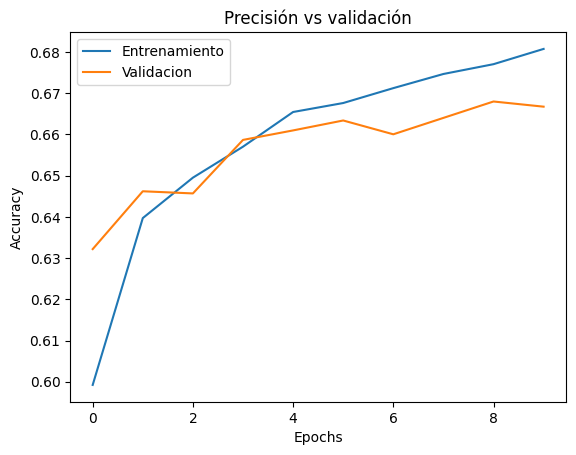

In [24]:
import matplotlib.pyplot as plt

plt.plot(history_mejorado.history['accuracy'])
plt.plot(history_mejorado.history['val_accuracy'])
plt.title("Precisión vs validación")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Entrenamiento", "Validacion"])
plt.show()